In [1]:
import numpy as np 
import pandas as pd

In [2]:

# Dataset load
df = pd.read_csv(r'/kaggle/input/datasets/mujammilshah/countries/Countries (1).csv')

# First 5 rows
df.head()

,country,country_long,currency,capital_city,region,continent,demonym,latitude,longitude,agricultural_land,...,population,women_parliament_seats_pct,rural_population,urban_population,press,democracy_score,democracy_type,median_age,political_leader,title
0,Afghanistan,Islamic State of Afghanistan,Afghan afghani,Kabul,Southern Asia,Asia,Afghan,33.0,65.0,383560.0,...,41128771,27.01610,30181937,10946834,2.14,2.97,Authoritarian,12.9,Ashraf Ghani,President
1,Albania,Republic of Albania,Albanian lek,Tirana,Southern Europe,Europe,Albanian,41.0,20.0,11655.5,...,2775634,35.71430,1004807,1770827,2.62,5.98,Hybrid regime,33.7,Edi Rama,Prime Minister
2,Algeria,People's Democratic Republic of Algeria,Algerian dinar,Algiers,Northern Africa,Africa,Algerian,28.0,3.0,413588.0,...,44903225,8.10811,11328186,33575039,1.71,3.50,Authoritarian,24.0,Abdelmadjid Tebboune,President
3,Andorra,Principality of Andorra,Euro,Andorra la Vella,Southern Europe,Europe,Andorran,42.5,1.5,187.2,...,79824,46.42860,9730,70094,3.17,0.00,Unknown,38.9,Xavier Espot Zamora,Head of Government
4,Angola,People's Republic of Angola,Angolan kwanza,Luanda,Middle Africa,Africa,Angolan,-12.5,18.5,569525.0,...,35588987,33.63640,11359649,24229338,2.24,3.62,Authoritarian,12.4,João Lourenço,President


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 64 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   country                                  194 non-null    object 
 1   country_long                             194 non-null    object 
 2   currency                                 194 non-null    object 
 3   capital_city                             194 non-null    object 
 4   region                                   194 non-null    object 
 5   continent                                194 non-null    object 
 6   demonym                                  194 non-null    object 
 7   latitude                                 194 non-null    float64
 8   longitude                                194 non-null    float64
 9   agricultural_land                        193 non-null    float64
 10  forest_area                              194 non-n

In [4]:
df.shape

(194, 64)

In [5]:
df.isnull().sum()

country             0
country_long        0
currency            0
capital_city        0
region              0
                   ..
democracy_score     0
democracy_type      0
median_age          0
political_leader    7
title               7
Length: 64, dtype: int64

In [6]:
df[['country','political_leader','title']]
[df['political_leader'].isnull()]

[0      False
 1      False
 2      False
 3      False
 4      False
        ...  
 189    False
 190     True
 191    False
 192    False
 193    False
 Name: political_leader, Length: 194, dtype: bool]

In [7]:
df.loc[df['political_leader'].isnull(), 
       ['country', 'political_leader', 'title']]

,country,political_leader,title
27,Cabo Verde,NaN,NaN
151,Slovak Republic,NaN,NaN
159,St. Kitts and Nevis,NaN,NaN
160,St. Lucia,NaN,NaN
161,St. Vincent and the Grenadines,NaN,NaN
172,Timor-Leste,NaN,NaN
190,West Bank and Gaza,NaN,NaN


In [8]:
(df.isnull().sum()/len(df))*100

country             0.000000
country_long        0.000000
currency            0.000000
capital_city        0.000000
region              0.000000
                      ...   
democracy_score     0.000000
democracy_type      0.000000
median_age          0.000000
political_leader    3.608247
title               3.608247
Length: 64, dtype: float64

In [9]:
df['political_leader'] = df['political_leader'].fillna('Unknown')
df['title'] = df['title'].fillna('Unknown')

In [10]:
df[['political_leader', 'title']].isnull().sum()

political_leader    0
title               0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,latitude,longitude,agricultural_land,forest_area,land_area,rural_land,urban_land,central_government_debt_pct_gdp,expense_pct_gdp,gdp,...,net_migration,population_female,population_male,population,women_parliament_seats_pct,rural_population,urban_population,press,democracy_score,median_age
count,194.000000,194.000000,1.930000e+02,1.940000e+02,1.940000e+02,1.940000e+02,194.000000,120.000000,156.000000,1.930000e+02,...,194.000000,1.940000e+02,1.940000e+02,1.940000e+02,193.000000,1.940000e+02,1.940000e+02,194.000000,194.000000,194.000000
mean,18.975601,22.027491,2.454551e+05,2.086784e+05,6.675087e+05,6.563711e+05,9777.116531,66.759366,30.051403,5.144851e+11,...,-51.407216,2.028316e+07,2.050572e+07,4.078888e+07,25.022994,1.763322e+07,2.315566e+07,2.539330,4.644536,25.661856
std,23.876225,66.396389,6.356268e+05,7.824926e+05,1.837107e+06,1.811169e+06,42301.458421,71.806247,26.740880,2.307148e+12,...,94525.968598,7.258941e+07,7.607158e+07,1.486470e+08,12.671044,7.664187e+07,7.940393e+07,1.800128,2.818297,9.415569
min,-41.000000,-175.000000,4.000000e+00,0.000000e+00,2.027000e+00,3.495450e-02,0.000000,0.000000,0.000267,6.034940e+07,...,-525116.000000,5.513000e+03,5.799000e+03,1.131200e+04,0.000000,0.000000e+00,5.717000e+03,0.000000,0.000000,10.500000
25%,4.000000,-5.000000,6.464000e+03,3.331775e+03,2.355250e+04,2.186562e+04,359.618250,31.951300,18.371875,1.181390e+10,...,-12242.250000,1.036218e+06,1.044902e+06,2.106358e+06,15.384600,5.896640e+05,1.222244e+06,1.525000,2.722500,16.950000
50%,16.583333,21.500000,3.872780e+04,2.528925e+04,1.203750e+05,1.159945e+05,1645.170000,55.426850,27.337750,4.115390e+10,...,-970.000000,4.502713e+06,4.450049e+06,9.125614e+06,25.252500,2.512382e+06,4.508837e+06,2.400000,5.050000,24.950000
75%,40.000000,50.162500,2.150000e+05,1.236735e+05,5.237000e+05,4.911505e+05,4054.022500,79.539300,35.083500,2.519450e+11,...,2904.250000,1.526606e+07,1.478872e+07,3.031361e+07,33.636400,1.133354e+07,1.621355e+07,2.925000,6.967500,34.050000
max,65.000000,178.000000,5.285080e+06,8.153120e+06,1.637690e+07,1.622420e+07,522345.000000,687.994000,310.443000,2.546270e+13,...,561580.000000,6.915285e+08,7.311805e+08,1.417173e+09,61.250000,9.088048e+08,8.975784e+08,10.000000,9.870000,50.500000


In [13]:
df .columns.tolist()

['country',
 'country_long',
 'currency',
 'capital_city',
 'region',
 'continent',
 'demonym',
 'latitude',
 'longitude',
 'agricultural_land',
 'forest_area',
 'land_area',
 'rural_land',
 'urban_land',
 'central_government_debt_pct_gdp',
 'expense_pct_gdp',
 'gdp',
 'inflation',
 'self_employed_pct',
 'tax_revenue_pct_gdp',
 'unemployment_pct',
 'vulnerable_employment_pct',
 'electricity_access_pct',
 'alternative_nuclear_energy_pct',
 'electricty_production_coal_pct',
 'electricty_production_hydroelectric_pct',
 'electricty_production_gas_pct',
 'electricty_production_nuclear_pct',
 'electricty_production_oil_pct',
 'electricty_production_renewable_pct',
 'energy_imports_pct',
 'fossil_energy_consumption_pct',
 'renewable_energy_consumption_pct',
 'co2_emissions',
 'methane_emissions',
 'nitrous_oxide_emissions',
 'greenhouse_other_emissions',
 'urban_population_under_5m',
 'health_expenditure_pct_gdp',
 'health_expenditure_capita',
 'hospital_beds',
 'hiv_incidence',
 'suicide_rat

In [14]:
df['country'].nunique()

194

In [15]:
df['continent'].value_counts()

continent
Africa      54
Asia        47
Europe      44
Americas    35
Oceania     14
Name: count, dtype: int64

In [16]:
df['region'].value_counts()

region
Eastern Africa               17
Western Asia                 17
Western Africa               16
Southern Europe              15
Caribbean                    13
South America                12
South-Eastern Asia           11
Northern Europe              10
Middle Africa                10
Eastern Europe               10
Western Europe                9
Southern Asia                 9
Central America               8
Northern Africa               6
Micronesia                    5
Southern Africa               5
Eastern Asia                  5
Central Asia                  5
Melanesia                     4
Polynesia                     3
Australia and New Zealand     2
Northern America              2
Name: count, dtype: int64

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

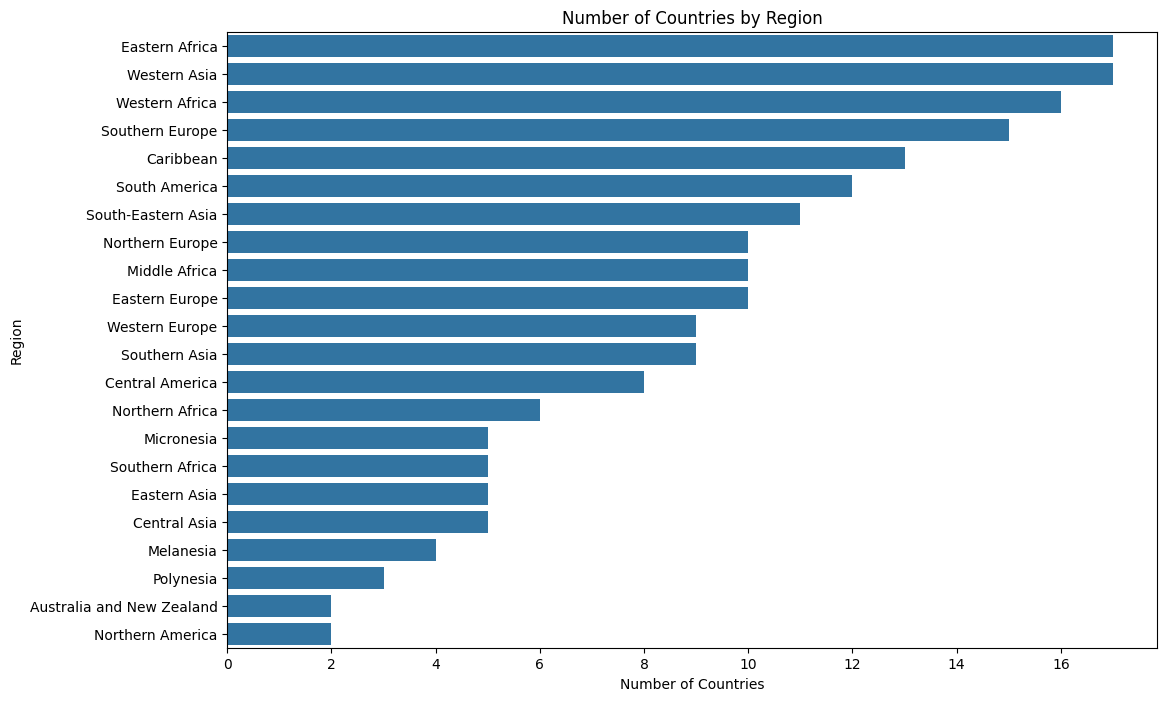

In [18]:
plt.figure(figsize=(12, 8))

sns.countplot(
    data=df,
    y='region',
    order=df['region'].value_counts().index
)

plt.title('Number of Countries by Region')
plt.xlabel('Number of Countries')
plt.ylabel('Region')

plt.show()

# 📊 Exploratory Data Analysis

## 🌍 Region-wise Country Distribution

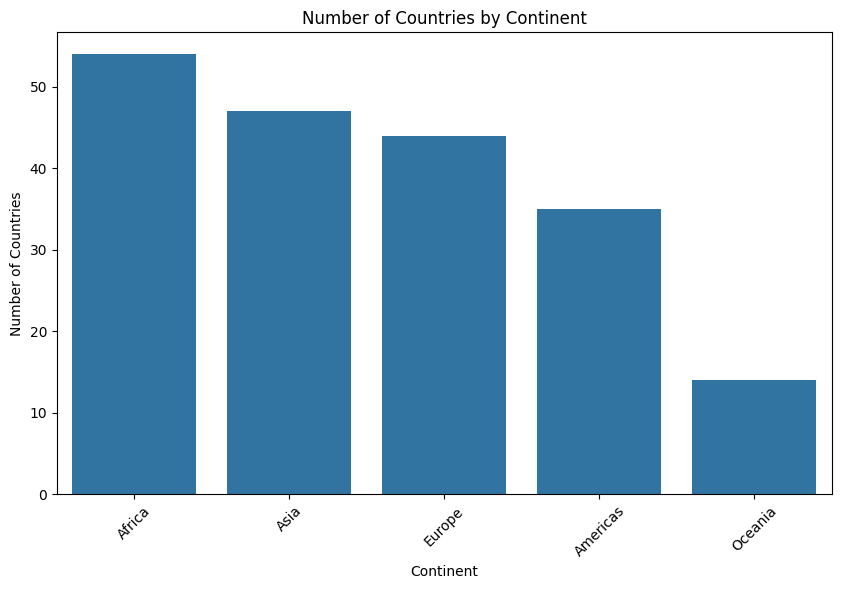

In [19]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='continent',
    order=df['continent'].value_counts().index
)

plt.title('Number of Countries by Continent')
plt.xlabel('Continent')
plt.ylabel('Number of Countries')

plt.xticks(rotation=45)

plt.show()

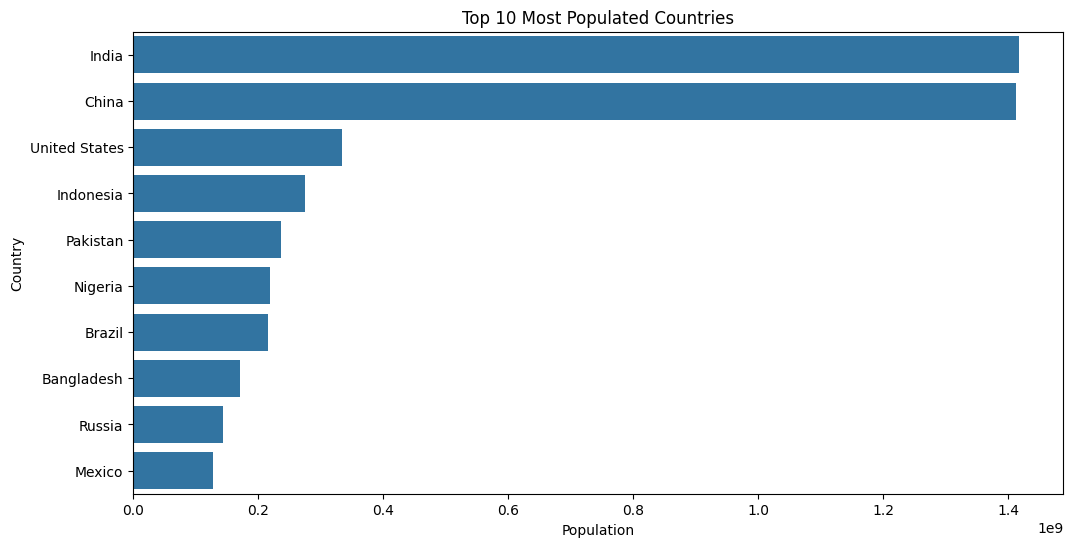

In [20]:
top_population = df.nlargest(10, 'population')

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_population,
    x='population',
    y='country'
)

plt.title('Top 10 Most Populated Countries')
plt.xlabel('Population')
plt.ylabel('Country')

plt.show()

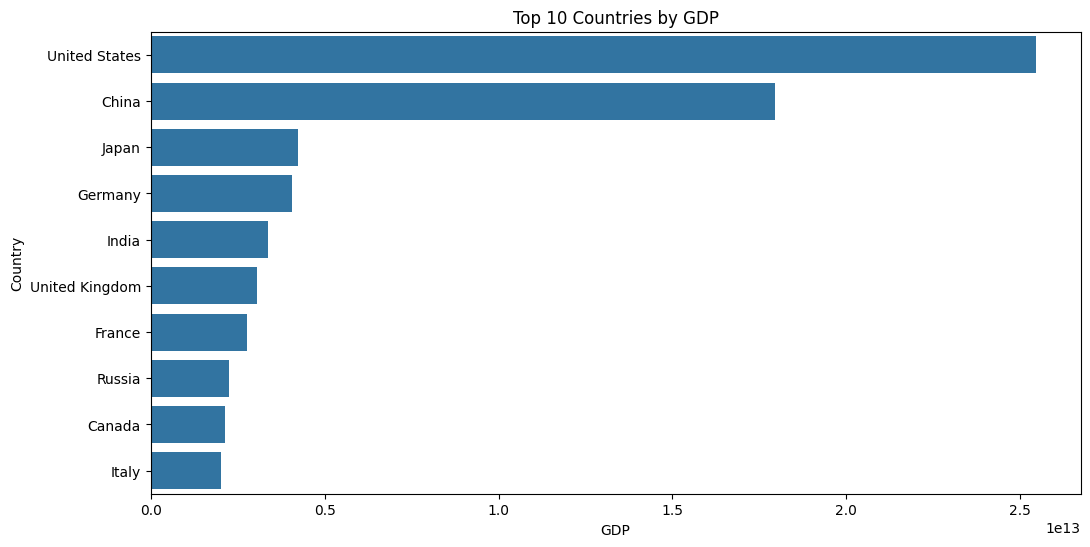

In [21]:
top_gdp = df.nlargest(10, 'gdp')

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_gdp,
    x='gdp',
    y='country'
)

plt.title('Top 10 Countries by GDP')
plt.xlabel('GDP')
plt.ylabel('Country')

plt.show()

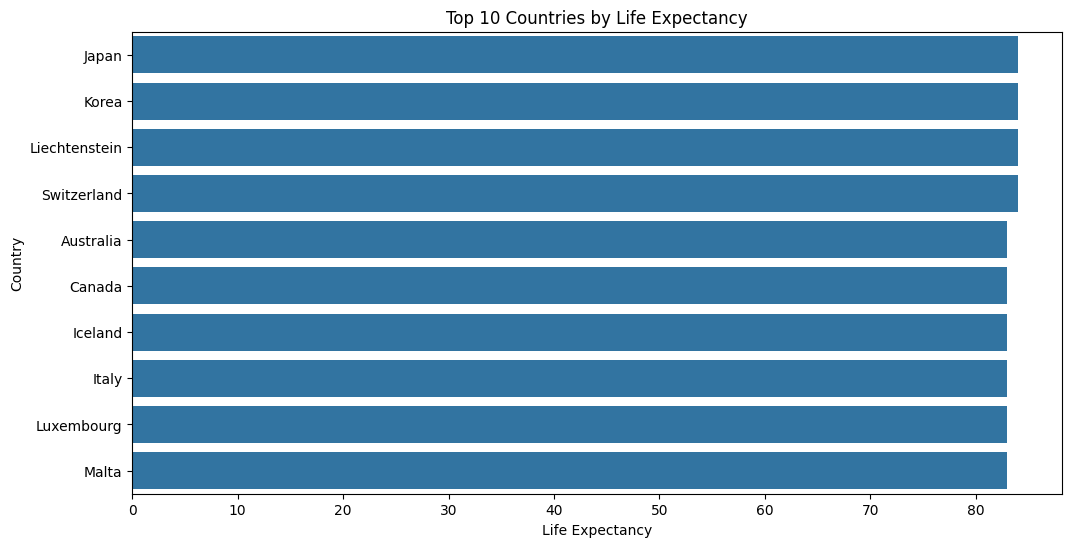

In [22]:
top_life = df.nlargest(10, 'life_expectancy')

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_life,
    x='life_expectancy',
    y='country'
)

plt.title('Top 10 Countries by Life Expectancy')
plt.xlabel('Life Expectancy')
plt.ylabel('Country')

plt.show()

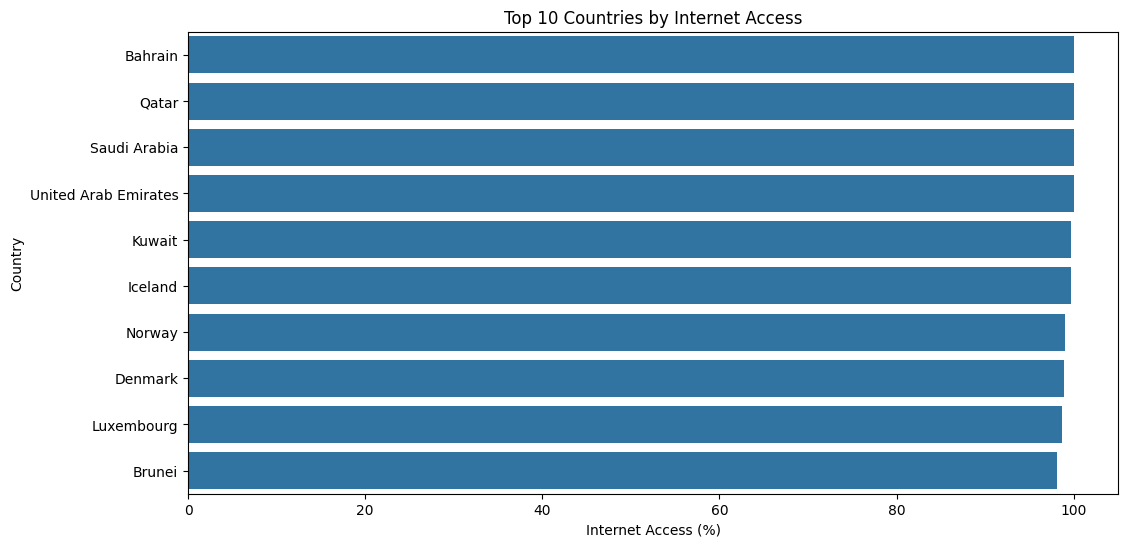

In [23]:
top_internet = df.nlargest(10, 'internet_pct')

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_internet,
    x='internet_pct',
    y='country'
)

plt.title('Top 10 Countries by Internet Access')
plt.xlabel('Internet Access (%)')
plt.ylabel('Country')

plt.show()

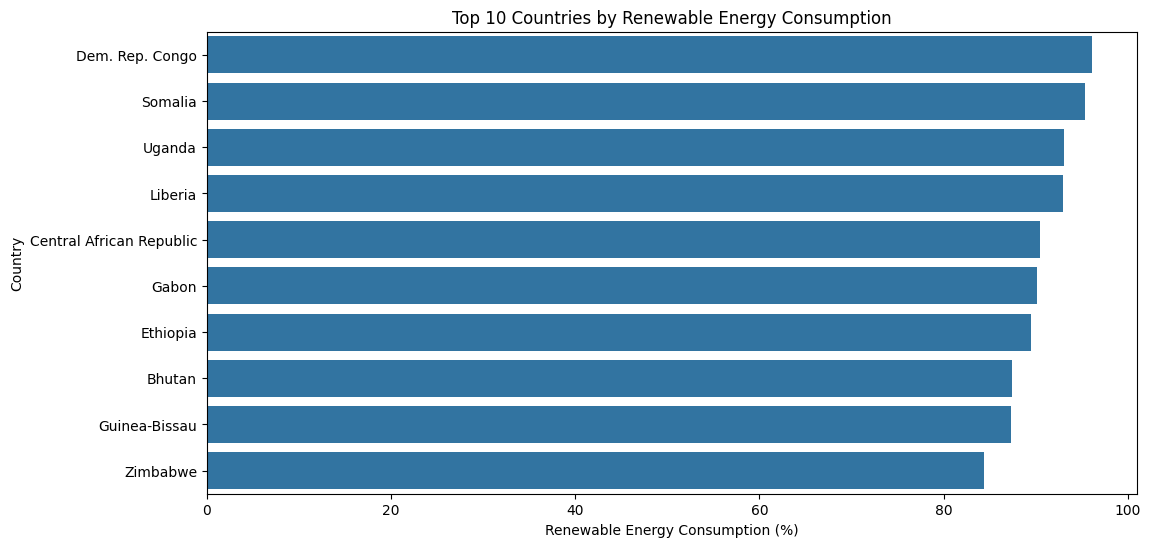

In [24]:
top_renewable = df.nlargest(10, 'renewable_energy_consumption_pct')

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_renewable,
    x='renewable_energy_consumption_pct',
    y='country'
)

plt.title('Top 10 Countries by Renewable Energy Consumption')
plt.xlabel('Renewable Energy Consumption (%)')
plt.ylabel('Country')

plt.show()

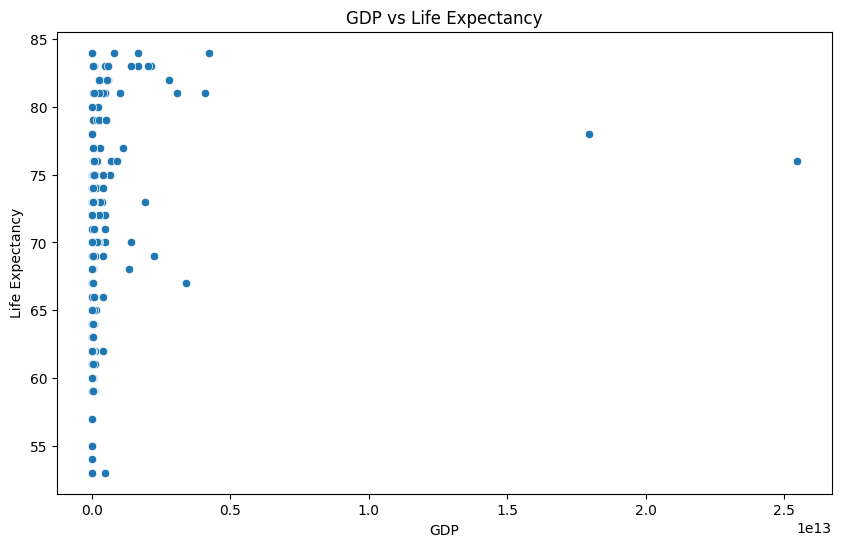

In [25]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='gdp',
    y='life_expectancy'
)

plt.title('GDP vs Life Expectancy')
plt.xlabel('GDP')
plt.ylabel('Life Expectancy')

plt.show()

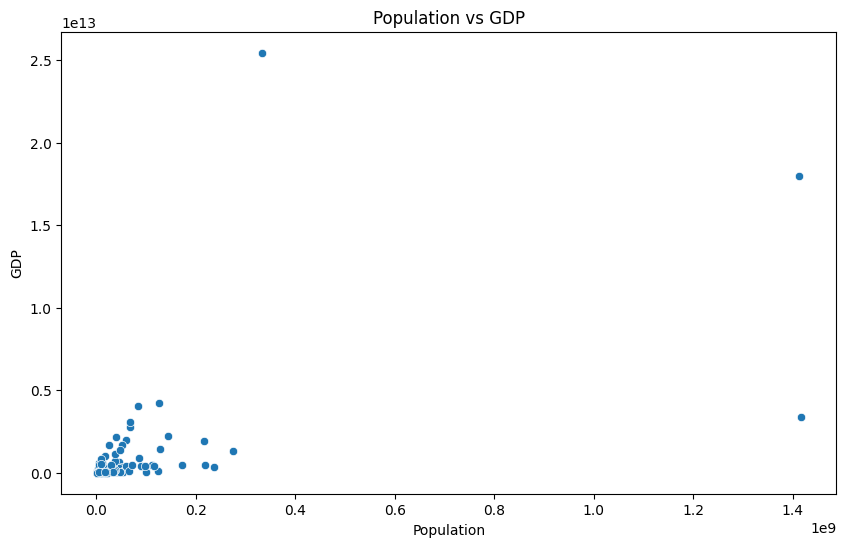

In [26]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='population',
    y='gdp'
)

plt.title('Population vs GDP')
plt.xlabel('Population')
plt.ylabel('GDP')

plt.show()

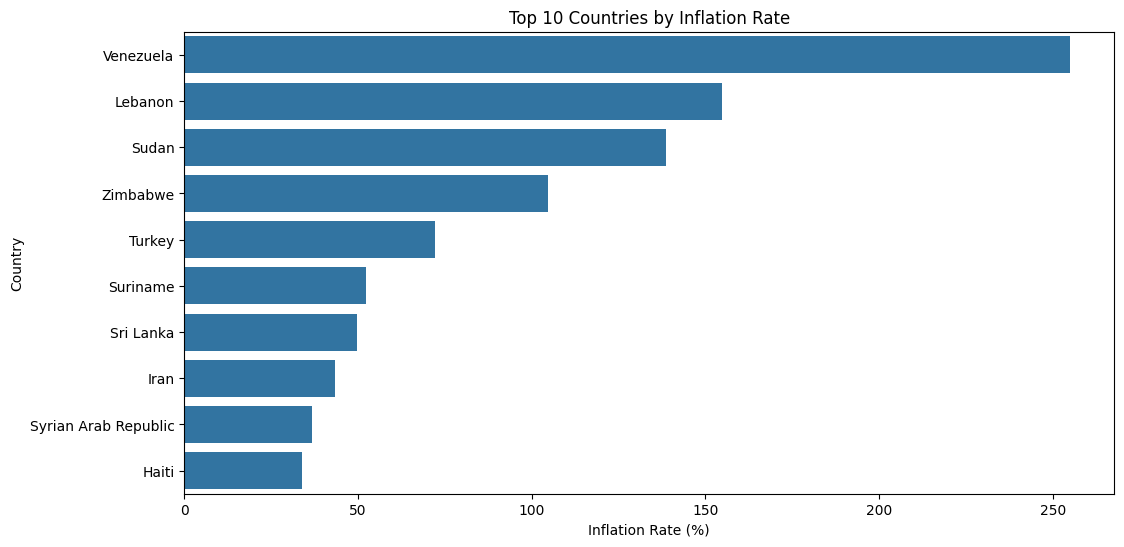

In [27]:
top_inflation = df.nlargest(10, 'inflation')

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_inflation,
    x='inflation',
    y='country'
)

plt.title('Top 10 Countries by Inflation Rate')
plt.xlabel('Inflation Rate (%)')
plt.ylabel('Country')

plt.show()

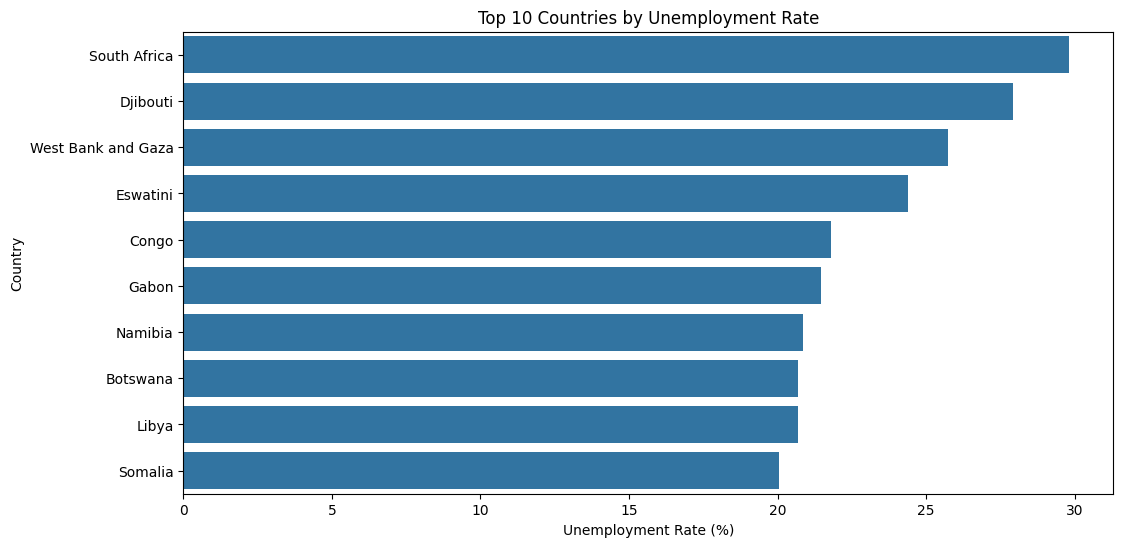

In [28]:
top_unemployment = df.nlargest(10, 'unemployment_pct')

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_unemployment,
    x='unemployment_pct',
    y='country'
)

plt.title('Top 10 Countries by Unemployment Rate')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Country')

plt.show()

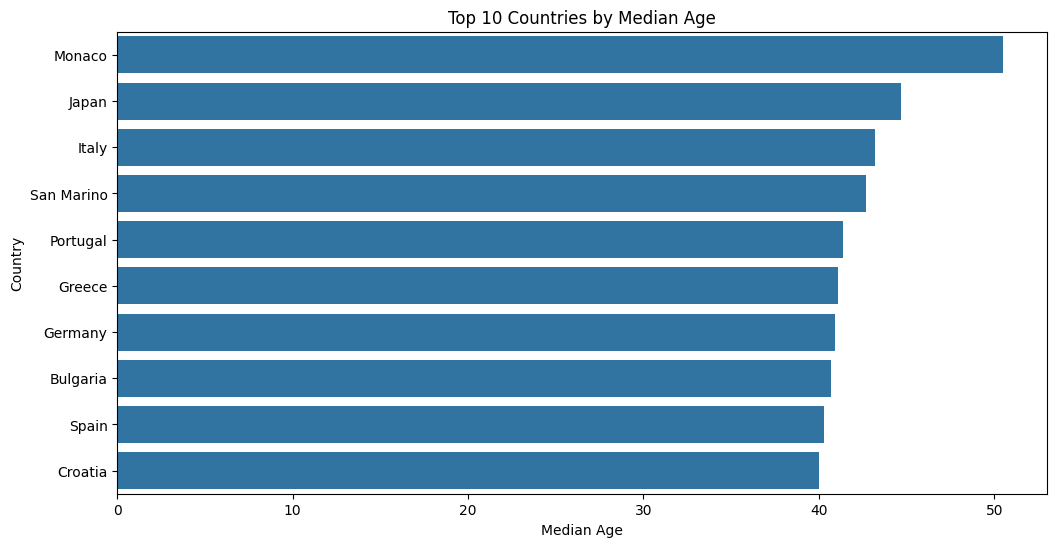

In [29]:
top_median_age = df.nlargest(10, 'median_age')

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_median_age,
    x='median_age',
    y='country'
)

plt.title('Top 10 Countries by Median Age')
plt.xlabel('Median Age')
plt.ylabel('Country')

plt.show()

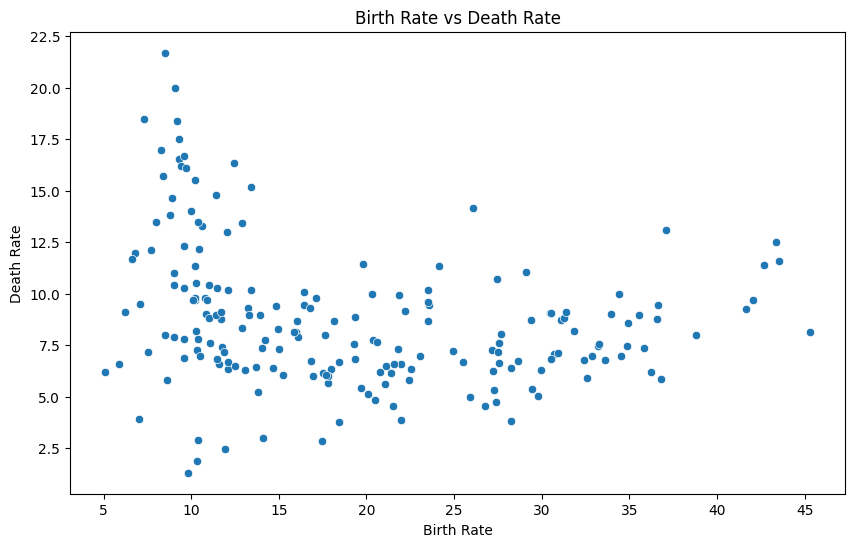

In [30]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='birth_rate',
    y='death_rate'
)

plt.title('Birth Rate vs Death Rate')
plt.xlabel('Birth Rate')
plt.ylabel('Death Rate')

plt.show()

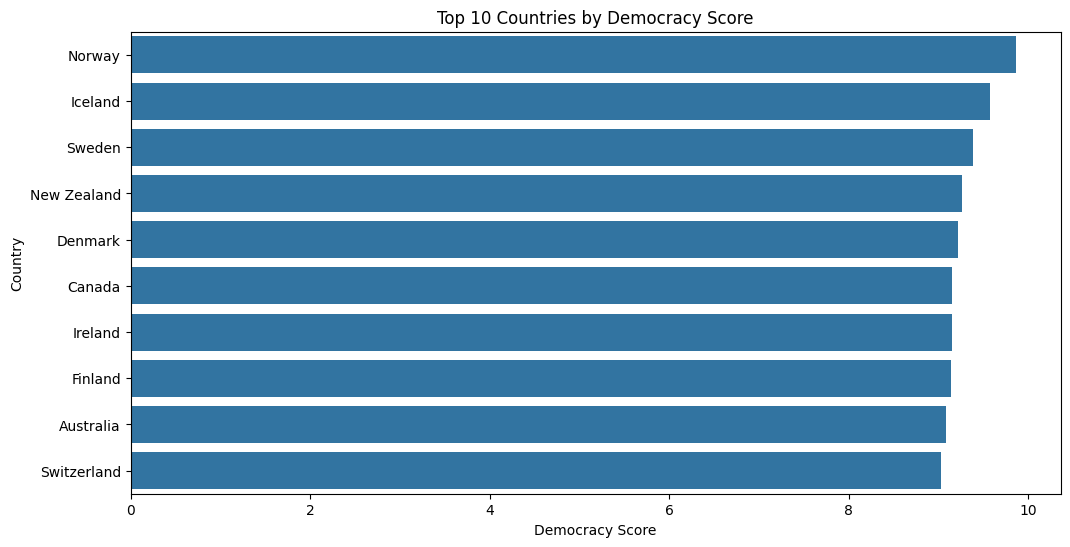

In [31]:
top_democracy = df.nlargest(10, 'democracy_score')

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_democracy,
    x='democracy_score',
    y='country'
)

plt.title('Top 10 Countries by Democracy Score')
plt.xlabel('Democracy Score')
plt.ylabel('Country')

plt.show()

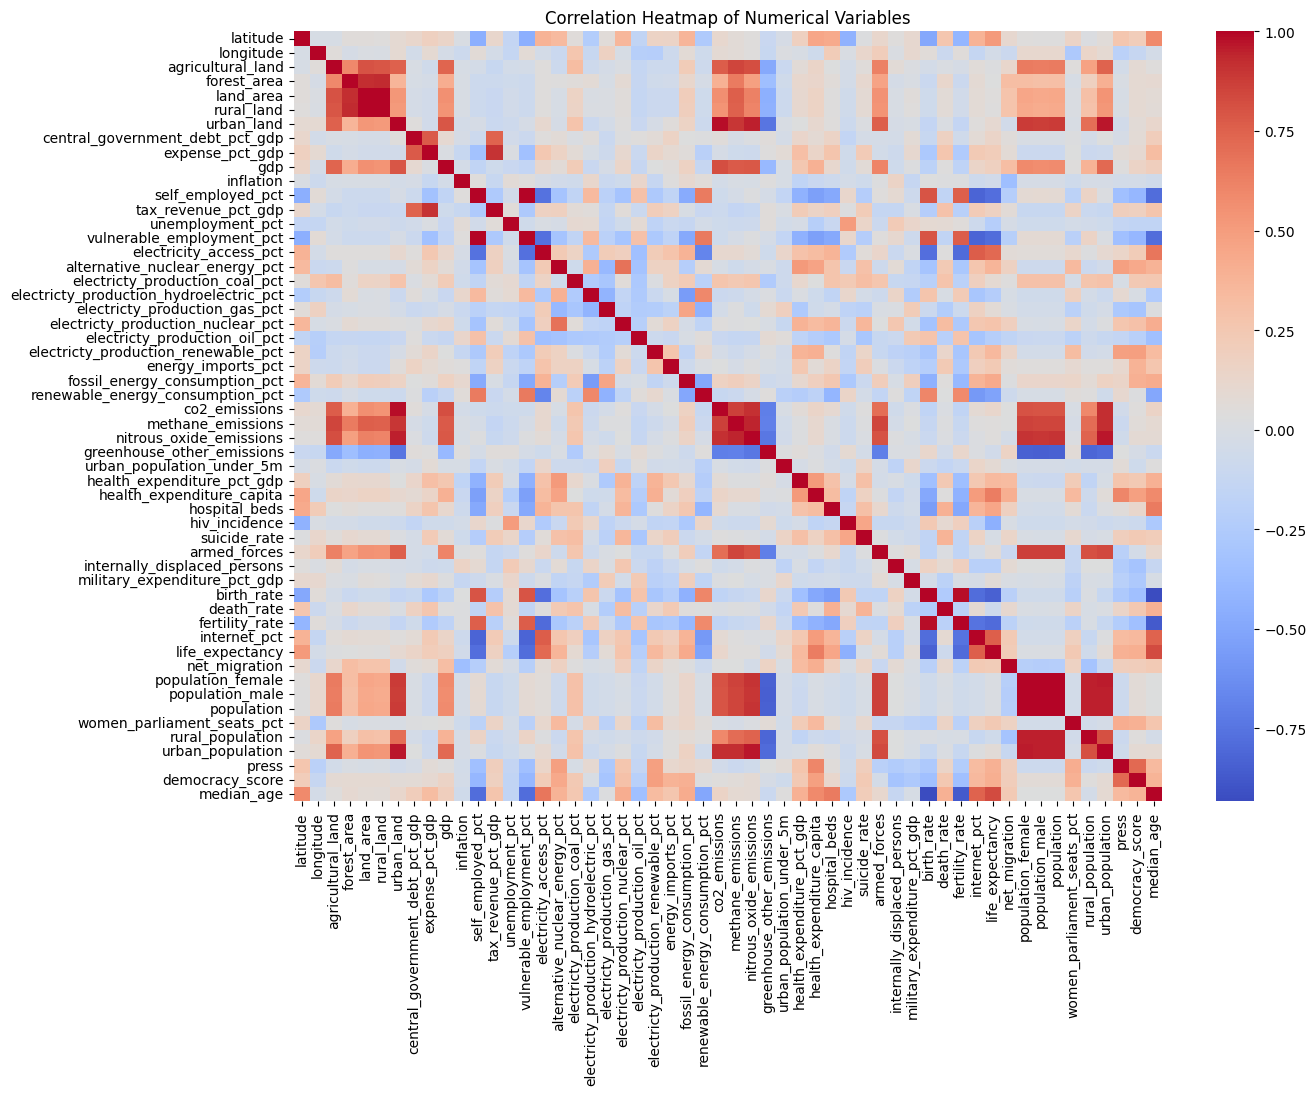

In [32]:
plt.figure(figsize=(14, 10))

numeric_df = df.select_dtypes(include='number')

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title('Correlation Heatmap of Numerical Variables')

plt.show()

# 🎯 Conclusion

This project analyzed a dataset containing information about 194 countries and 64 different variables.

## Key Findings

- The dataset includes geographical, economic, demographic, health, energy, and political information.
- Country distribution varies across different regions and continents.
- Population and GDP show significant differences between countries.
- Life expectancy, internet access, and healthcare-related indicators provide useful insights into development.
- Renewable energy consumption and other environmental indicators help analyze sustainability.
- The correlation heatmap helps identify relationships between numerical variables.

## Final Outcome

This Exploratory Data Analysis (EDA) provides useful insights into global country-level data and demonstrates the use of Python, Pandas, Matplotlib, and Seaborn for data analysis and visualization.